## Amazon EU BSR Share 분석

In [41]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math

In [4]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [5]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [86]:
sql = f"""
select * from vs1.amz_eu_bsr_shr_daily_acc
where bsr_date >= '2024-01-01' and rank <= 50
"""

df = bqclient.query(sql).to_dataframe()

In [88]:
print(df)

        country   bsr_ctgry        asin  rank    bsr_date  \
0            SE  Mattresses  B09R7M6NG6    40  2024-08-08   
1            UK  Mattresses  B0BQ334CHK    22  2024-10-07   
2            DE  Mattresses  B07QPPT2D1     5  2024-08-06   
3            UK  Mattresses  B0DD72F5NY     3  2025-04-27   
4            UK  Mattresses  B09XK6V8SW     2  2024-12-29   
...         ...         ...         ...   ...         ...   
5518393      DE      Chairs  B0D45631TH    28  2024-11-17   
5518394      DE      Chairs  B092J8KM37    20  2025-03-15   
5518395      DE      Chairs  B0C6M2JS6J    19  2024-12-22   
5518396      DE      Chairs  B0CWHCL462    26  2025-06-22   
5518397      DE      Chairs  B0BNB2PLRT    28  2024-02-03   

                                        brand  \
0                                      XDREAM   
1                                  WOWTTRELAX   
2                                 TRÄUMEGUT24   
3                                     TWIREST   
4                     

In [19]:
# ✅ brand 컬럼 대문자 변환
df['brand'] = df['brand'].str.upper()

# ✅ groupby 단위: country, bsr_ctgry, yr_week
# 전체 row 수
weekly_total = (
    df.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# ZINUS row 수
weekly_zinus = (
    df[df['brand'] == 'ZINUS']
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# ✅ 병합 후 점유율 계산
result = pd.merge(
    weekly_total, weekly_zinus,
    on=['country', 'bsr_ctgry', 'yr_week'],
    how='left'
)

# 결측치는 0으로 처리
result['zinus_count'] = result['zinus_count'].fillna(0)

# 점유율 계산
result['zinus_share'] = result['zinus_count'] / result['total_count']

# 보기 좋게 정렬
result = result.sort_values(['country', 'bsr_ctgry', 'yr_week']).reset_index(drop=True)

# 결과 확인
print(result.head(20))


   country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0       BE  Bed Frames  Y24 W01          780         35.0     0.044872
1       BE  Bed Frames  Y24 W02          910         32.0     0.035165
2       BE  Bed Frames  Y24 W03          908         79.0     0.087004
3       BE  Bed Frames  Y24 W04          910         75.0     0.082418
4       BE  Bed Frames  Y24 W05          910          6.0     0.006593
5       BE  Bed Frames  Y24 W06          910         12.0     0.013187
6       BE  Bed Frames  Y24 W07          910          0.0     0.000000
7       BE  Bed Frames  Y24 W08          910          4.0     0.004396
8       BE  Bed Frames  Y24 W09          910          7.0     0.007692
9       BE  Bed Frames  Y24 W10          910          2.0     0.002198
10      BE  Bed Frames  Y24 W11          910          0.0     0.000000
11      BE  Bed Frames  Y24 W12          910          2.0     0.002198
12      BE  Bed Frames  Y24 W13          910          2.0     0.002198
13    

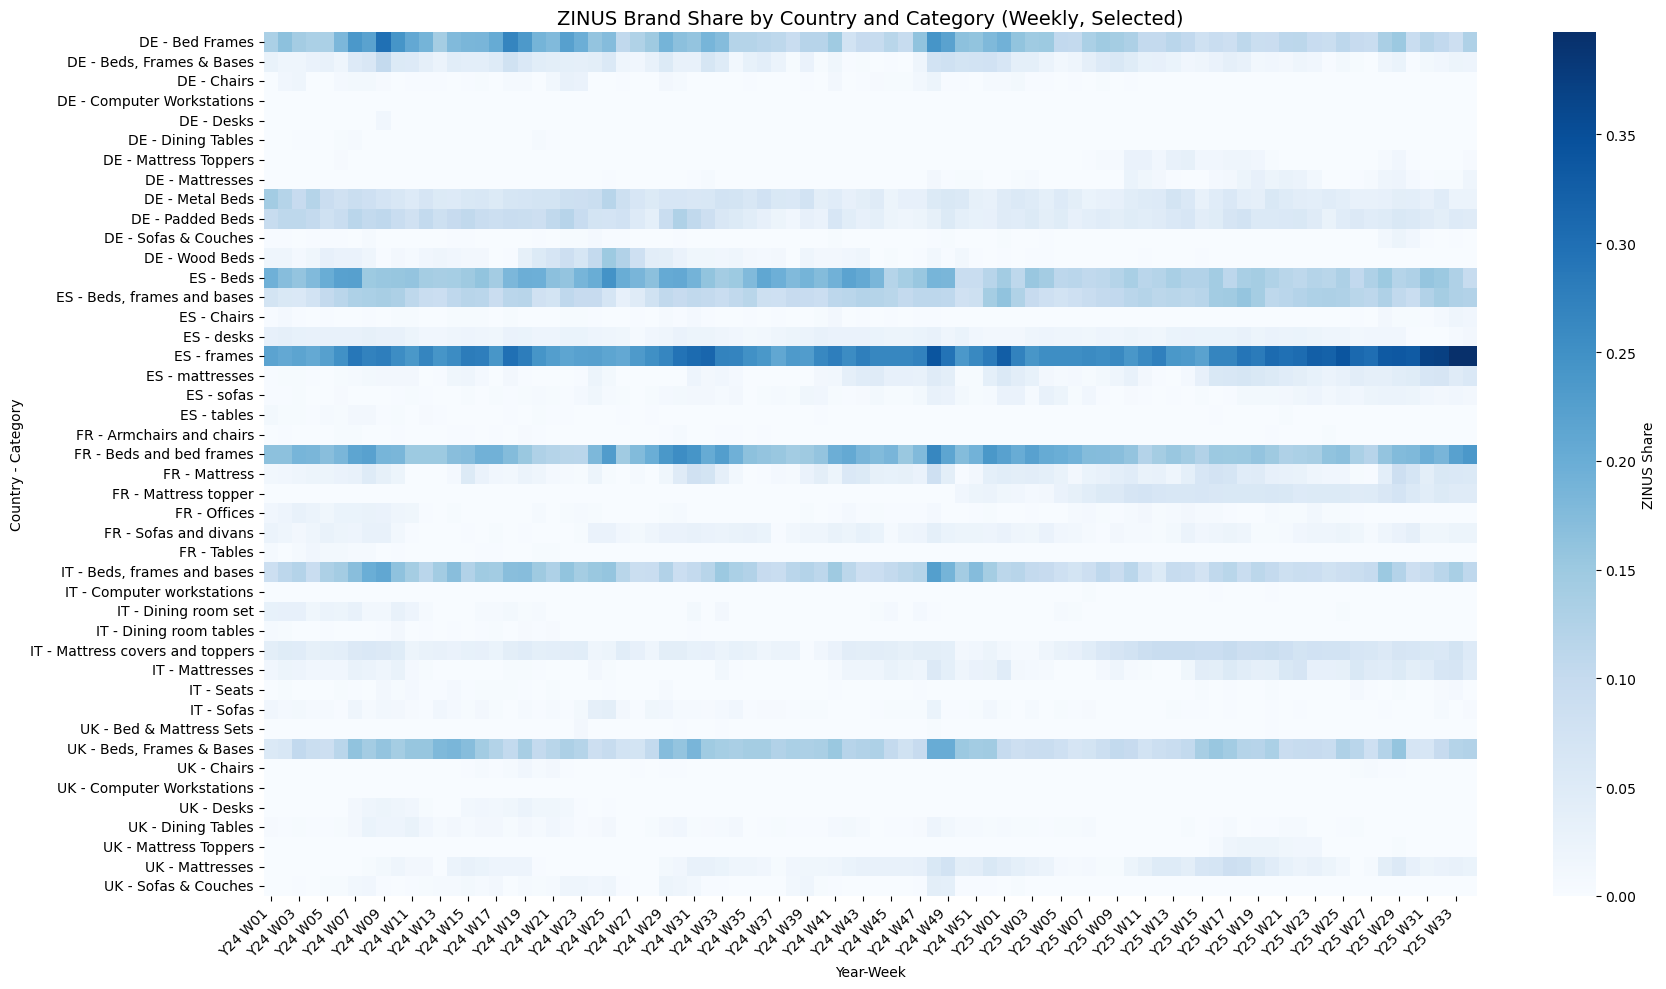

In [31]:

# ✅ 대상 국가만 필터링
target_countries = ["UK", "IT", "FR", "ES", "DE"]
filtered = result[result['country'].isin(target_countries)].copy()

# ✅ 제외할 국가-카테고리 정의
exclude_pairs = [
    ("UK", "Bed Frames"),
    ("IT", "Beds"),
    ("IT", "Bed structures"),
    ("FR", "Beds"),
    ("FR", "bed frames"),
    ("ES", "slatted bed bases"),
    ("ES", "Beds, structures and bases"),
    ("ES", "bed bases"),
    ("DE", "Slatted Divan Bases & Foundations")
]

# ✅ 제외 조건 적용
for c, cat in exclude_pairs:
    filtered = filtered[~((filtered['country'] == c) & (filtered['bsr_ctgry'] == cat))]

# ✅ Pivot 테이블 생성
pivot_table = filtered.pivot_table(
    index=['country', 'bsr_ctgry'],
    columns='yr_week',
    values='zinus_share',
    aggfunc='mean'
)

# 보기 좋게 인덱스 정리
pivot_table.index = [f"{c} - {cat}" for c, cat in pivot_table.index]

# ✅ 히트맵 그리기
plt.figure(figsize=(18, 10))
sns.heatmap(
    pivot_table,
    cmap="Blues",
    annot=False,
    cbar_kws={'label': 'ZINUS Share'}
)

plt.title("ZINUS Brand Share by Country and Category (Weekly, Selected)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Country - Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

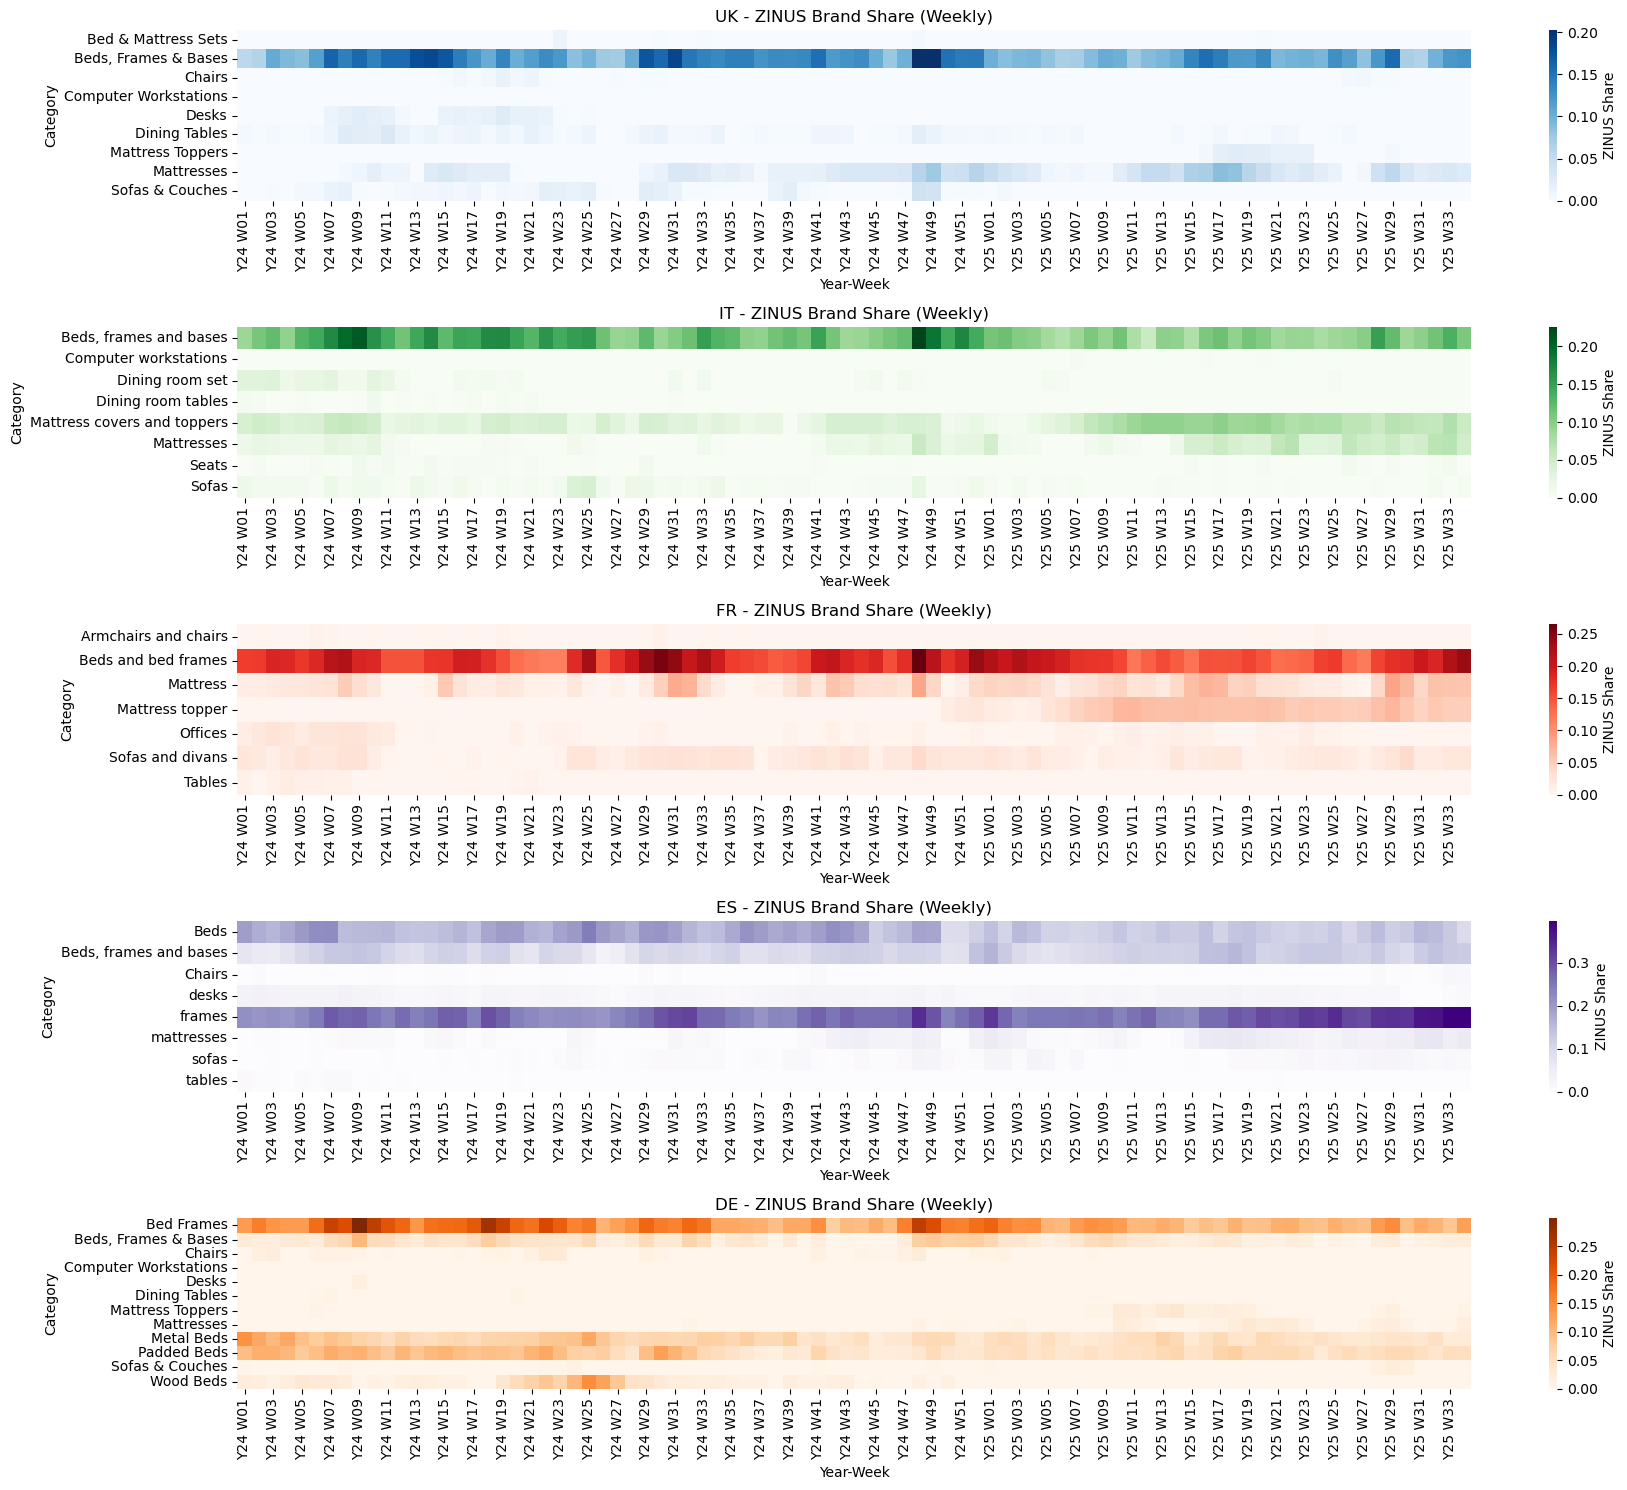

In [33]:

# ✅ 대상 국가
target_countries = ["UK", "IT", "FR", "ES", "DE"]

# ✅ 국가별로 다른 컬러맵 지정
cmaps = {
    "UK": "Blues",
    "IT": "Greens",
    "FR": "Reds",
    "ES": "Purples",
    "DE": "Oranges"
}

# ✅ subplot 생성
fig, axes = plt.subplots(len(target_countries), 1, figsize=(18, 3*len(target_countries)))

for ax, country in zip(axes, target_countries):
    data_cty = filtered[filtered['country'] == country]
    pivot_cty = data_cty.pivot_table(
        index='bsr_ctgry',
        columns='yr_week',
        values='zinus_share',
        aggfunc='mean'
    )

    sns.heatmap(
        pivot_cty,
        cmap=cmaps[country],
        annot=False,
        cbar_kws={'label': 'ZINUS Share'},
        ax=ax
    )
    ax.set_title(f"{country} - ZINUS Brand Share (Weekly)", fontsize=12)
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

C:\Users\최태욱\AppData\Local\Temp\ipykernel_2540\2011699048.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_map = agg_total.groupby(['country','bsr_ctgry']).apply(lambda g: select_top10(g,K)).reset_index()


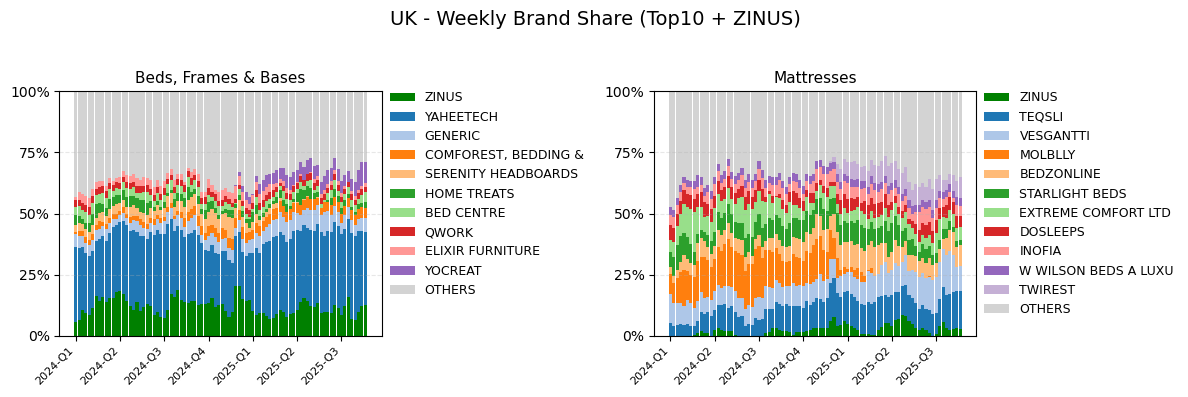

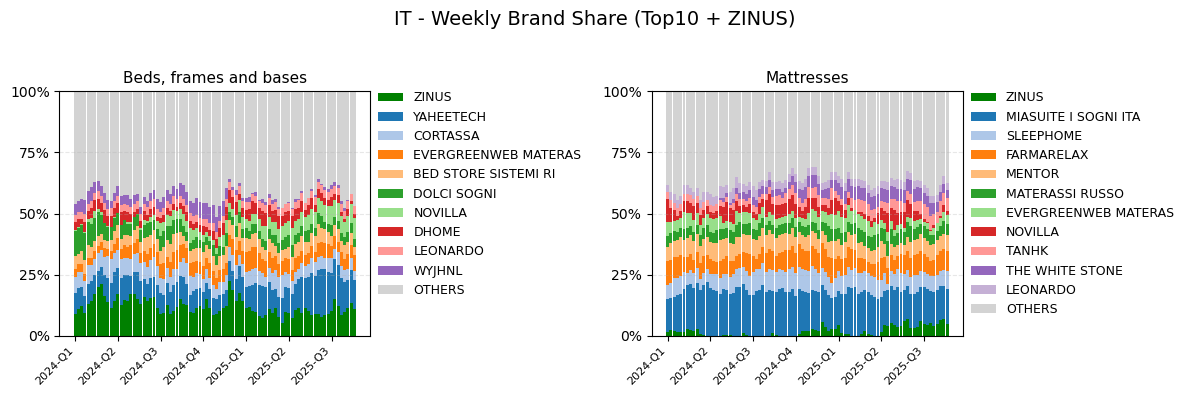

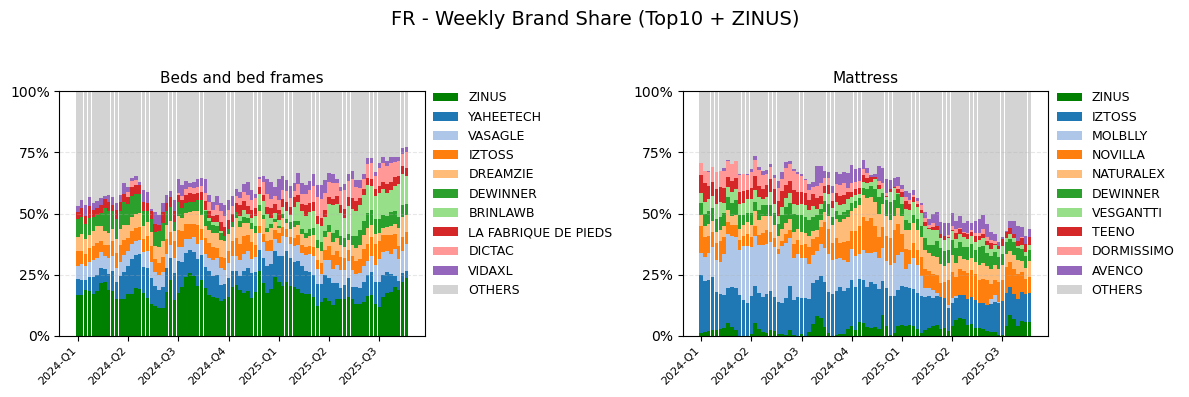

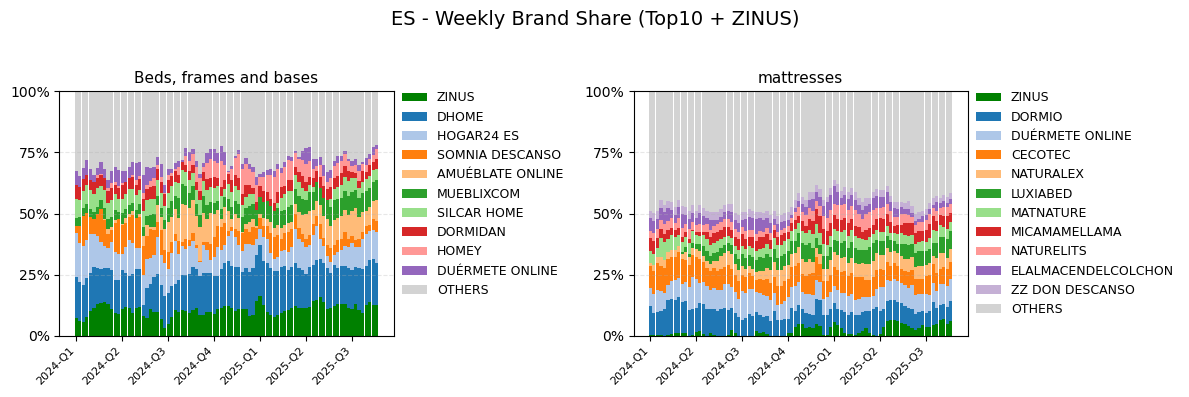

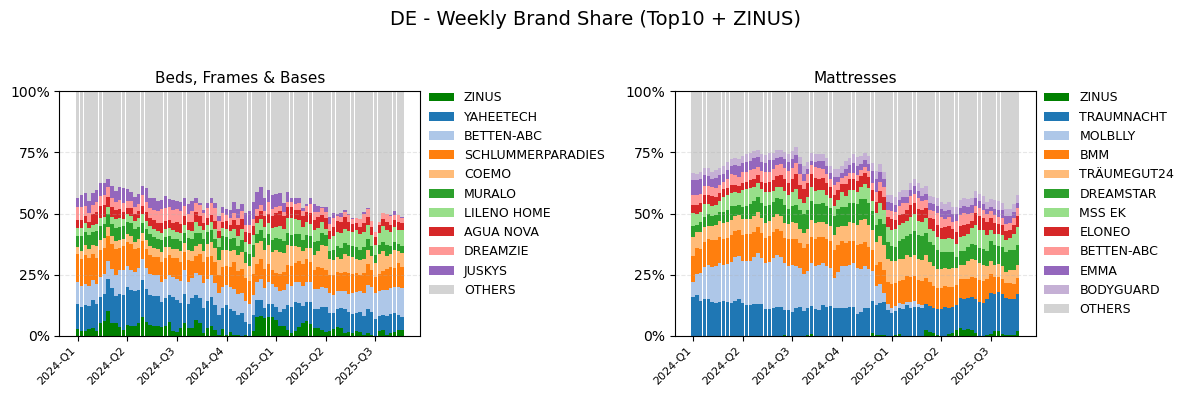

In [99]:
df = df.copy()
df['brand'] = df['brand'].str.upper()

# 1) 대상 국가/카테고리만 포함
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"]
}
mask_list = []
for c, cats in allowed_pairs.items():
    mask_list.append((df['country'] == c) & (df['bsr_ctgry'].isin(cats)))
df = df[np.logical_or.reduce(mask_list)].copy()

# 2) 주차 정렬 키
def parse_yrweek(s):
    if pd.isna(s):
        return (0, 0)
    m = re.search(r'Y(\d{2})\s*W(\d{2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (0, 0)

# 3) 주별 카운트 & 점유율
tot = df.groupby(['country','bsr_ctgry','yr_week']).size().reset_index(name='total_count')
by_brand = df.groupby(['country','bsr_ctgry','yr_week','brand']).size().reset_index(name='brand_count')
share = by_brand.merge(tot, on=['country','bsr_ctgry','yr_week'])
share['brand_share'] = share['brand_count'] / share['total_count']

# 4) Top10 + ZINUS 포함
K=10
agg_total = share.groupby(['country','bsr_ctgry','brand'])['brand_count'].sum().reset_index()
def select_top10(g,k=K):
    brands=set()
    if 'ZINUS' in g['brand'].values: brands.add('ZINUS')
    brands.update(g.sort_values('brand_count',ascending=False).head(k)['brand'].tolist())
    return pd.Series({'top_brands':list(brands)})
top_map = agg_total.groupby(['country','bsr_ctgry']).apply(lambda g: select_top10(g,K)).reset_index()
share = share.merge(top_map,on=['country','bsr_ctgry'],how='left')
share['brand_compact'] = share.apply(lambda r: r['brand'] if r['brand'] in set(r['top_brands']) else 'OTHERS',axis=1)

# 5) 재집계
comp = share.groupby(['country','bsr_ctgry','yr_week','brand_compact'])['brand_share'].sum().reset_index()

# 6) 국가별 Figure
countries = ['UK','IT','FR','ES','DE']
for country in countries:
    sub_country = comp[comp['country']==country].copy()
    if sub_country.empty: continue
    cats = sorted(sub_country['bsr_ctgry'].unique())
    ncols=2; nrows=math.ceil(len(cats)/ncols)
    fig,axes = plt.subplots(nrows,ncols,figsize=(6*ncols,4*nrows),squeeze=False)
    fig.suptitle(f"{country} - Weekly Brand Share (Top10 + ZINUS)",fontsize=14,y=0.98)

    for i,cat in enumerate(cats):
        ax = axes[i//ncols,i%ncols]
        sub=sub_country[sub_country['bsr_ctgry']==cat].copy()
        if sub.empty: 
            ax.axis('off')
            continue
    
        weeks=sorted(sub['yr_week'].unique(),key=parse_yrweek)
        pivot=(sub.pivot_table(index='yr_week',columns='brand_compact',
                               values='brand_share',aggfunc='sum')
                  .reindex(index=weeks).fillna(0.0))
    
        if 'ZINUS' not in pivot.columns: pivot['ZINUS']=0.0
        if 'OTHERS' not in pivot.columns: pivot['OTHERS']=0.0
    
        # 열 순서 정렬
        col_sums=pivot.sum(axis=0)
        rest=[c for c in pivot.columns if c not in ('ZINUS','OTHERS')]
        rest_sorted=list(pd.Series(col_sums[rest]).sort_values(ascending=False).index)
        stack_order=['ZINUS']+rest_sorted+['OTHERS']
        pivot=pivot[stack_order]
    
        # 100% 정규화
        pivot = pivot.div(pivot.sum(axis=1).replace(0,1),axis=0)
    
        # 색상 팔레트
        base_colors=plt.cm.tab20.colors
        color_map={'ZINUS':'green','OTHERS':'lightgray'}
        for j,br in enumerate([b for b in pivot.columns if b not in ('ZINUS','OTHERS')]):
            color_map[br]=base_colors[j % len(base_colors)]
    
        # 막대 그리기
        bottom=np.zeros(len(pivot))
        x=np.arange(len(pivot.index))
        handles,labels=[],[]
        for col in pivot.columns:
            h=ax.bar(x,pivot[col].values,bottom=bottom,width=0.9,
                     label=col if len(col)<=20 else col[:20],
                     color=color_map[col])
            handles.append(h[0]); labels.append(col if len(col)<=20 else col[:20])
            bottom+=pivot[col].values
    
        ax.set_title(cat,fontsize=11)
        ax.set_ylim(0,1)
        ax.set_yticks([0,.25,.5,.75,1.0]); ax.set_yticklabels(['0%','25%','50%','75%','100%'])
    
        # ✅ 분기별 대표 tick만 출력
        year_quarter = {}
        for w in pivot.index:
            y, wk = parse_yrweek(w)
            q = (wk-1)//13 + 1   # 1~13 → Q1, 14~26 → Q2 ...
            key = f"{y}-Q{q}"
            if key not in year_quarter:  # 분기 첫 번째 주차만 저장
                year_quarter[key] = w
    
        xticks = [weeks.index(v) for v in year_quarter.values()]
        xticklabels = list(year_quarter.keys())
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels,rotation=45,ha='right',fontsize=8)
    
        #ax.set_xlabel("Quarter")
        #ax.set_ylabel("Share")
        ax.grid(axis='y',linestyle='--',alpha=0.3)
    
        # Legend (각 그래프마다)
        ax.legend(handles,labels,loc='upper left',
                  bbox_to_anchor=(1.01,1.02),borderaxespad=0.,fontsize=9,frameon=False)

    # 빈축 제거
    for j in range(i+1,nrows*ncols): axes[j//ncols,j%ncols].axis('off')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

In [90]:
df3 = df.copy()
df_es = df3[df3['country']=='ES']

In [91]:
df_es.groupby('bsr_ctgry').count()

,country,asin,rank,bsr_date,brand,title,image_url,bsr_ctgry_label,pdt_url,yr_month,yr_week,is_maxdt,is_maxdt_range,bsr_ord,brand_prod_num,brand_ord,date_str,bsr_rank_range,brand_legend_ord
bsr_ctgry,,,,,,,,,,,,,,,,,,,
Beds,77888,77888,77888,77888,77888,77882,77882,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
"Beds, frames and bases",77897,77897,77897,77897,77897,77895,77895,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897
"Beds, structures and bases",77915,77915,77915,77915,77915,77913,77913,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915
Chairs,77887,77887,77887,77887,77887,77885,77885,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887
bed bases,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
desks,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900
frames,77890,77890,77890,77890,77890,77883,77883,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
mattresses,77918,77918,77918,77918,77918,77914,77914,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918
slatted bed bases,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
